# H1. Различия времени доставки между штатами

## 1. Постановка задачи

### Бизнес-вопрос

Различается ли время доставки заказов в зависимости от штата покупателя?

### Нулевая гипотеза H0

Распределение времени доставки одинаково для всех штатов.

### Альтернативная гипотеза H1

Распределение времени доставки различается хотя бы для одного штата.

### Метод

Для проверки гипотезы используется критерий Краскела–Уоллиса, поскольку:

- время доставки является количественным признаком;
- сравнивается более двух независимых групп;
- распределение времени доставки содержит выраженную асимметрию и выбросы;
- тест не требует предположения о нормальности распределений.

Если общий тест покажет статистически значимые различия, дополнительно используется post-hoc тест Данна с поправкой Холма для множественных сравнений.

Уровень значимости:
alpha = 0.05

## 2. Подготовка окружения

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

import scikit_posthocs as sp
from scipy import stats

from sqlalchemy import create_engine
from sqlalchemy.engine import URL

In [2]:
import os
from dotenv import load_dotenv

In [3]:
_ = load_dotenv()

In [4]:
DB_USERNAME = os.getenv("DB_USERNAME")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

url = URL.create(
    drivername="postgresql+psycopg2",
    username=DB_USERNAME,
    password=DB_PASSWORD,
    host=DB_HOST,
    port=DB_PORT,
    database=DB_NAME,
)

In [5]:
engine = create_engine(url=url)

## 3. Получение данных

Для анализа используются только доставленные заказы, для которых известны дата покупки, дата фактической доставки и штат покупателя.

Для каждого заказа рассчитывается время доставки в днях:

\[
delivery\_days =
delivery\_date - purchase\_date
\]


In [6]:
query = """
SELECT
    o.order_id,
    EXTRACT(
        EPOCH FROM (
            o.order_delivered_customer_date
            - o.order_purchase_timestamp
        )
    ) / 86400.0 AS delivery_days,
    c.customer_state
FROM orders AS o
JOIN customers AS c
    ON o.customer_id = c.customer_id
WHERE
    o.order_status = 'delivered'
    AND o.order_purchase_timestamp IS NOT NULL
    AND o.order_delivered_customer_date IS NOT NULL
    AND c.customer_state IS NOT NULL;
"""

df = pd.read_sql(sql=query, con=engine)

## 4. Проверка качества данных

Перед статистическим анализом проверим:

- размер выборки;
- количество представленных штатов;
- отсутствие пропущенных значений;
- отсутствие отрицательного времени доставки;
- уникальность заказов после объединения таблиц.


In [7]:
df.head()

,order_id,delivery_days,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,8.436574,SP
1,53cdb2fc8bc7dce0b6741e2150273451,13.782037,BA
2,47770eb9100c2d0c44946d9cf07ec65d,9.394213,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,13.208750,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,2.873877,SP


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 96470 entries, 0 to 96469
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        96470 non-null  str    
 1   delivery_days   96470 non-null  float64
 2   customer_state  96470 non-null  str    
dtypes: float64(1), str(2)
memory usage: 2.2 MB


In [9]:
quality_checks = pd.Series({
    "rows": len(df),
    "unique_orders": df["order_id"].nunique(),
    "duplicate_orders": df["order_id"].duplicated().sum(),
    "states": df["customer_state"].nunique(),
    "missing_values": df.isna().sum().sum(),
    "negative_delivery_days": (df["delivery_days"] < 0).sum(),
})

quality_checks

rows                      96470
unique_orders             96470
duplicate_orders              0
states                       27
missing_values                0
negative_delivery_days        0
dtype: int64

In [10]:
df["delivery_days"].describe().round(2)

count    96470.00
mean        12.56
std          9.55
min          0.53
25%          6.77
50%         10.22
75%         15.72
max        209.63
Name: delivery_days, dtype: float64

## 5. Описательный анализ

Сначала рассмотрим общее распределение времени доставки, затем сравним показатели между штатами.


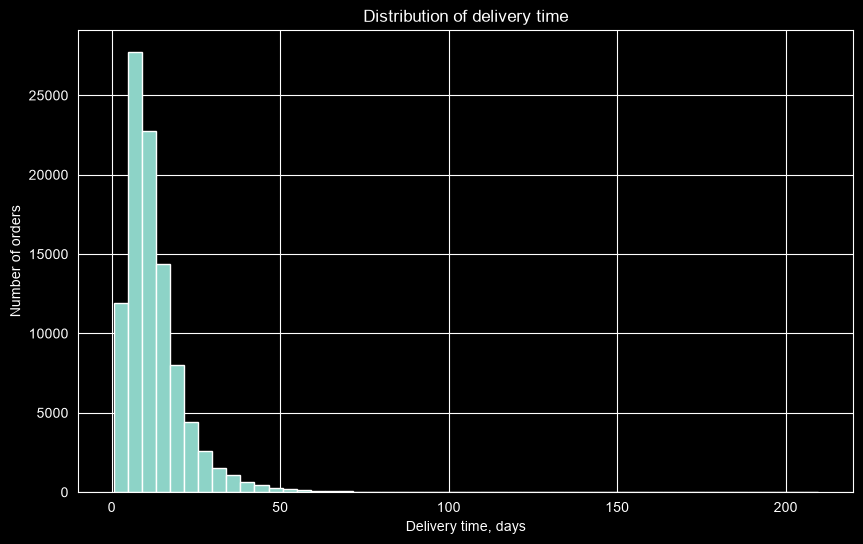

In [11]:
plt.figure(figsize=(10, 6))

plt.hist(df["delivery_days"], bins=50)

plt.title("Distribution of delivery time")
plt.xlabel("Delivery time, days")
plt.ylabel("Number of orders")

plt.show()

### 5.1. Описательная статистика по штатам

Рассчитаем число заказов, среднее, медиану, стандартное отклонение и межквартильный диапазон времени доставки для каждого штата.


In [12]:
state_stats = (
    df.groupby("customer_state")["delivery_days"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
    )
    .sort_values("median")
    .round(2)
)

state_stats

,count,mean,median,std,q25,q75
customer_state,,,,,,
SP,40494,8.76,7.21,6.75,4.82,10.94
MG,11354,12.01,10.31,7.20,7.40,14.56
PR,4923,11.99,10.43,6.98,7.47,14.58
DF,2080,12.97,11.36,7.06,8.09,16.07
RJ,12350,15.31,12.04,11.52,8.11,18.47
SC,3546,14.95,13.01,8.58,9.00,18.77
RS,5344,15.30,13.18,9.18,9.39,18.51
ES,1995,15.79,13.64,10.64,9.97,18.93
MS,701,15.62,13.94,7.73,10.34,18.64


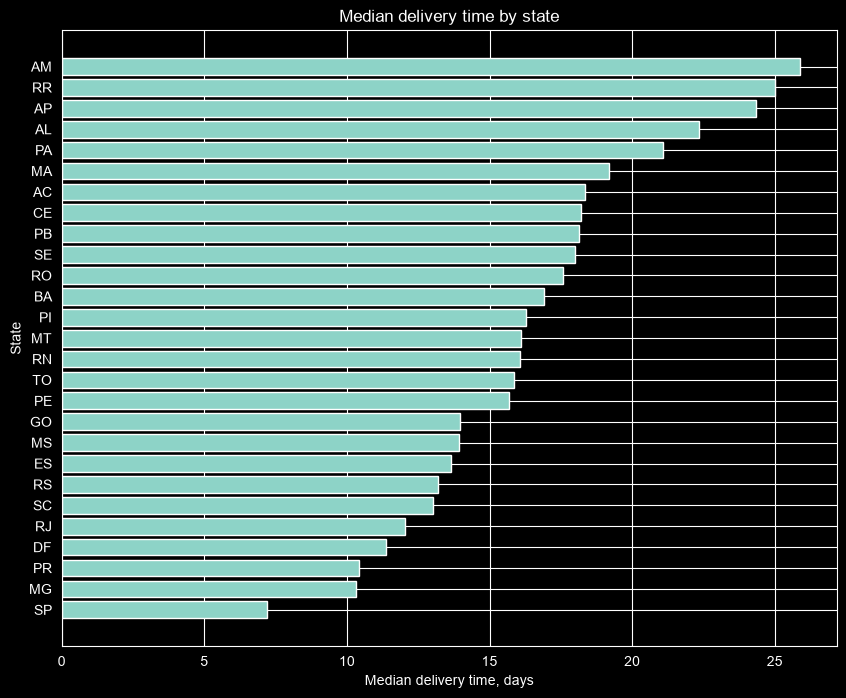

In [13]:
plt.figure(figsize=(10, 8))

plt.barh(
    state_stats.index,
    state_stats["median"]
)

plt.title("Median delivery time by state")
plt.xlabel("Median delivery time, days")
plt.ylabel("State")

plt.show()

### 5.2. Распределение времени доставки по штатам

Сравним распределения времени доставки между штатами. Выбросы на boxplot скрыты только для удобства визуального сравнения и не удаляются из данных, используемых в статистическом тесте.


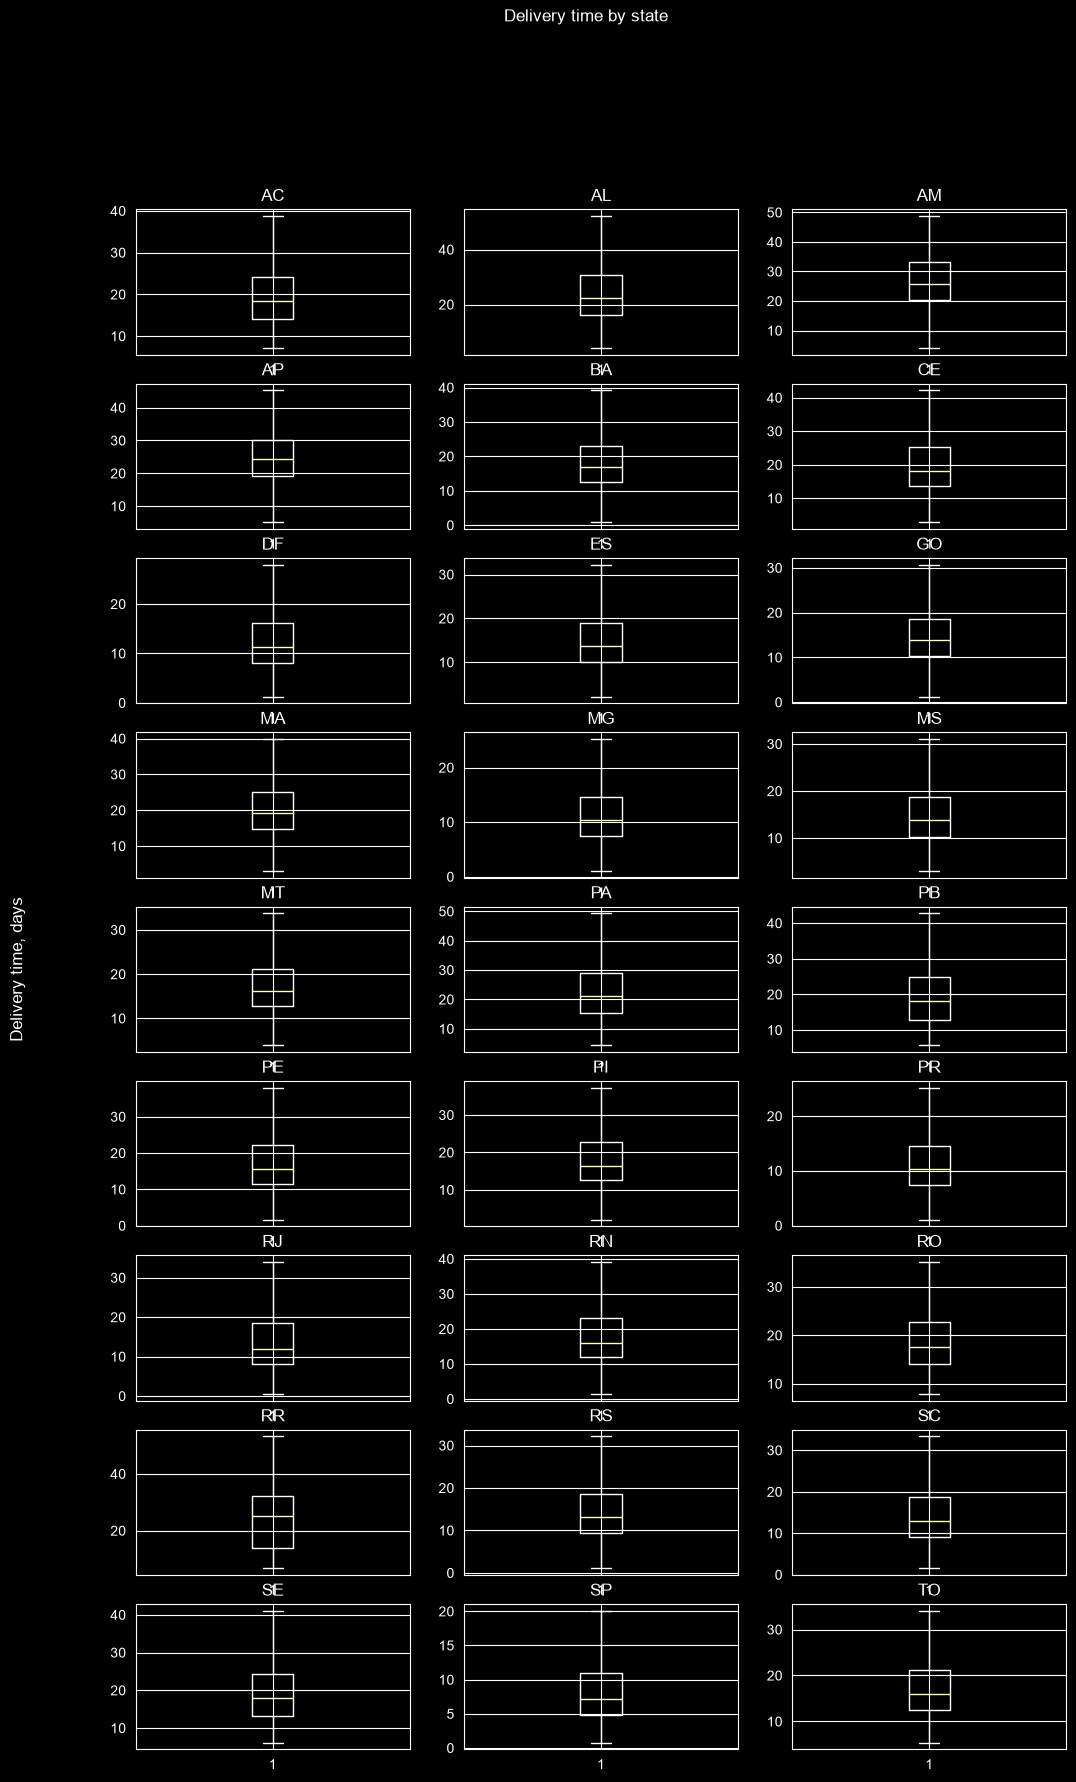

In [24]:
delivery_by_state = [(i_state, i_df['delivery_days'].to_numpy()) for i_state, i_df in df.groupby("customer_state")]

fig, ax = plt.subplots(nrows=9, ncols=3, figsize=(12, 20))

fig.suptitle("Delivery time by state")
fig.supylabel('Delivery time, days')

ax_flat = ax.flatten()

for index, i_group in enumerate(delivery_by_state):
    state = i_group[0]
    delivery_time_days = i_group[1]

    ax_flat[index].boxplot(
        delivery_time_days,
        showfliers=False)
    ax_flat[index].set_title(state)

plt.show()

## 6. Проверка статистической гипотезы

Для сравнения времени доставки между 27 независимыми группами используется критерий Краскела–Уоллиса.

Критерий принятия решения:

- если (p < 0.05), нулевая гипотеза отвергается;
- если (p >= 0.0\), оснований для отклонения нулевой гипотезы недостаточно.

Важно: критерий Краскела–Уоллиса показывает наличие различий хотя бы между двумя группами, но сам по себе не определяет, какие именно штаты различаются.


In [25]:
ALPHA = 0.05

delivery_by_state = [
    group["delivery_days"].to_numpy()
    for _, group in df.groupby("customer_state")
]

kruskal_result = stats.kruskal(*delivery_by_state)

h_statistic = kruskal_result.statistic
p_value = kruskal_result.pvalue

print(f"Kruskal-Wallis H: {h_statistic:.4f}")

if p_value < 0.001:
    print("p-value: < 0.001")
else:
    print(f"p-value: {p_value:.4f}")

if p_value < ALPHA:
    print("Reject H0")
    print("Delivery-time distributions differ between at least two states.")
else:
    print("Fail to reject H0")
    print("There is insufficient evidence of differences between states.")

Kruskal-Wallis H: 24168.3077
p-value: < 0.001
Reject H0
Delivery-time distributions differ between at least two states.


## 7. Размер эффекта

При большой выборке статистическая значимость может возникать даже при небольших различиях. Поэтому дополнительно рассчитаем epsilon^2 — размер эффекта для критерия Краскела–Уоллиса.

Чем больше значение epsilon^2, тем заметнее различия между группами.


In [26]:
n = len(df)
k = df["customer_state"].nunique()

epsilon_squared = (h_statistic - k + 1) / (n - k)
epsilon_squared = max(0, epsilon_squared)

print(f"Epsilon squared: {epsilon_squared:.4f}")

Epsilon squared: 0.2503


## 8. Post-hoc анализ

Если критерий Краскела–Уоллиса отвергает нулевую гипотезу, выполним попарный тест Данна.

Для контроля ошибки множественных сравнений используется поправка Холма.


In [27]:
if p_value < ALPHA:
    dunn_matrix = sp.posthoc_dunn(
        df,
        val_col="delivery_days",
        group_col="customer_state",
        p_adjust="holm",
    )

    dunn_matrix.round(4)
else:
    print("Post-hoc analysis is not required because H0 was not rejected.")

In [28]:
if p_value < ALPHA:
    states = dunn_matrix.columns.to_list()
    significant_pairs = []

    for i, state_1 in enumerate(states):
        for j in range(i + 1, len(states)):
            state_2 = states[j]
            adjusted_p = dunn_matrix.loc[state_1, state_2]

            if adjusted_p < ALPHA:
                significant_pairs.append({
                    "state_1": state_1,
                    "state_2": state_2,
                    "adjusted_p_value": adjusted_p,
                })

    significant_pairs = (
        pd.DataFrame(significant_pairs)
        .sort_values("adjusted_p_value")
        .reset_index(drop=True)
    )

    print(f"Significant pairs: {len(significant_pairs)}")
    significant_pairs.head(20)

Significant pairs: 236


## 9. Итоговая таблица


In [29]:
results = pd.DataFrame({
    "metric": [
        "Kruskal-Wallis H",
        "p-value",
        "epsilon squared",
        "alpha",
    ],
    "value": [
        h_statistic,
        p_value,
        epsilon_squared,
        ALPHA,
    ],
})

results

,metric,value
0,Kruskal-Wallis H,24168.307716
1,p-value,0.000000
2,epsilon squared,0.250327
3,alpha,0.050000


## 10. Результаты и вывод

В исходном анализе критерий Краскела–Уоллиса показал статистически значимые различия времени доставки между штатами:

- Kruskal-Wallis H: 24168.31;
- p < 0.001;
- epsilon^2: 0.25.

Нулевая гипотеза отвергается: распределение времени доставки статистически значимо различается между штатами.

Описательная статистика также показывает заметный региональный разброс. Например, медианное время доставки составляло около **7.2 дня в SP**, тогда как для ряда удалённых штатов оно превышало **20 дней**.

### Бизнес-интерпретация

Регион покупателя связан со скоростью доставки. Это означает, что единая оценка логистического SLA для всей страны может скрывать существенные региональные различия.

Для дальнейшего анализа стоит:

- определить пары штатов со статистически значимыми различиями с помощью post-hoc теста;
- сопоставить результаты с расстоянием до продавцов и логистической инфраструктурой;
- отдельно изучить штаты с наиболее высоким медианным временем доставки;
- учитывать размер выборки по штатам при интерпретации результатов.

Статистический тест показывает связь между штатом и распределением времени доставки, но сам по себе не устанавливает причинно-следственный механизм.